# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [1]:
# Imports
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# Create connection to database
conn = sqlite3.connect('data.sqlite')

### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.
*Hint*: Make sure creditLimit is numeric.

In [2]:
# creditLimit is stored as TEXT, so CAST it to a number before comparing.
# (A text comparison would be alphabetical, e.g. '9000.00' > '25000.00'.)
ca_high_credit_customers = pd.read_sql("""
SELECT customerNumber,
       customerName,
       contactFirstName,
       contactLastName,
       phone,
       city,
       state,
       CAST(creditLimit AS REAL) AS creditLimit
  FROM customers
 WHERE state = 'CA'
   AND CAST(creditLimit AS REAL) > 25000
 ORDER BY creditLimit DESC;
""", conn)
ca_high_credit_customers

,customerNumber,customerName,contactFirstName,contactLastName,phone,city,state,creditLimit
0,124,Mini Gifts Distributors Ltd.,Susan,Nelson,4155551450,San Rafael,CA,210500.0
1,239,Collectable Mini Designs Co.,Valarie,Thompson,7605558146,San Diego,CA,105000.0
2,321,Corporate Gift Ideas Co.,Julie,Brown,6505551386,San Francisco,CA,105000.0
3,205,Toys4GrownUps.com,Julie,Young,6265557265,Pasadena,CA,90700.0
4,161,Technics Stores Inc.,Juri,Hashimoto,6505556809,Burlingame,CA,84600.0
5,450,The Sharp Gifts Warehouse,Sue,Frick,4085553659,San Jose,CA,77600.0
6,129,Mini Wheels Co.,Julie,Murphy,6505555787,San Francisco,CA,64600.0
7,487,Signal Collectibles Ltd.,Sue,Taylor,4155554312,Brisbane,CA,60300.0
8,347,"Men 'R' US Retailers, Ltd.",Brian,Chandler,2155554369,Los Angeles,CA,57700.0
9,475,West Coast Collectables Co.,Steve,Thompson,3105553722,Burbank,CA,55400.0


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [3]:
# TRIM guards against stray whitespace in country values (e.g. 'Norway  ').
# LIKE '%Collect%' matches "Collect" anywhere in the name
# (Collectables, Collectors, Collections, ...).
intl_collect_customers = pd.read_sql("""
SELECT customerNumber,
       customerName,
       contactFirstName,
       contactLastName,
       city,
       country
  FROM customers
 WHERE TRIM(country) != 'USA'
   AND customerName LIKE '%Collect%'
 ORDER BY country, customerName;
""", conn)
intl_collect_customers

,customerNumber,customerName,contactFirstName,contactLastName,city,country
0,471,"Australian Collectables, Ltd",Sean,Clenahan,Glen Waverly,Australia
1,114,"Australian Collectors, Co.",Peter,Ferguson,Melbourne,Australia
2,382,Salzburg Collectables,Georg,Pipps,Salzburg,Austria
3,260,"Royal Canadian Collectables, Ltd.",Elizabeth,Lincoln,Tsawassen,Canada
4,227,Heintze Collectables,Palle,Ibsen,Århus,Denmark
5,353,Reims Collectables,Paul,Henriot,Reims,France
6,415,"Bavarian Collectables Imports, Co.",Michael,Donnermeyer,Munich,Germany
7,409,Stuttgart Collectable Exchange,Rita,Müller,Stuttgart,Germany
8,211,"King Kong Collectables, Co.",Mike,Gao,Central Hong Kong,Hong Kong
9,189,"Clover Collections, Co.",Dean,Cassidy,Dublin,Ireland


## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

**Answer:**

The WHERE clause works like a two-part checklist, and a customer must pass **both** checks (that is what `AND` does) to appear in the list:

1. **`TRIM(country) != 'USA'`**: keep only customers whose country is *not* the USA. The `!=` operator means "not equal to". `TRIM` first strips any accidental blank spaces from the stored country name, so a messy entry such as "Norway␣␣" is still read correctly as "Norway".
2. **`customerName LIKE '%Collect%'`**: keep only customers whose name contains the word "Collect". The `%` signs are wildcards that mean "any text can come before or after", so this catches "Collect**ables**", "Collect**ors**", "Collect**ions**", and so on, wherever the word appears in the name.

Because both conditions must be true, a US store called "Collectables For Less Inc." is excluded, and an international store without "Collect" in its name is excluded too. The result is exactly the international "Collect" partners that were asked for.

### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [4]:
usa_credit_by_state = pd.read_sql("""
SELECT state,
       COUNT(*)                                  AS num_customers,
       ROUND(AVG(CAST(creditLimit AS REAL)), 2)  AS avg_credit_limit
  FROM customers
 WHERE country = 'USA'
 GROUP BY state
 ORDER BY avg_credit_limit DESC;
""", conn)
usa_credit_by_state

,state,num_customers,avg_credit_limit
0,NH,1,114200.00
1,NY,6,89966.67
2,PA,3,84766.67
3,CA,11,83854.55
4,NV,1,71800.00
5,MA,9,70755.56
6,CT,4,57350.00
7,NJ,1,43000.00


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

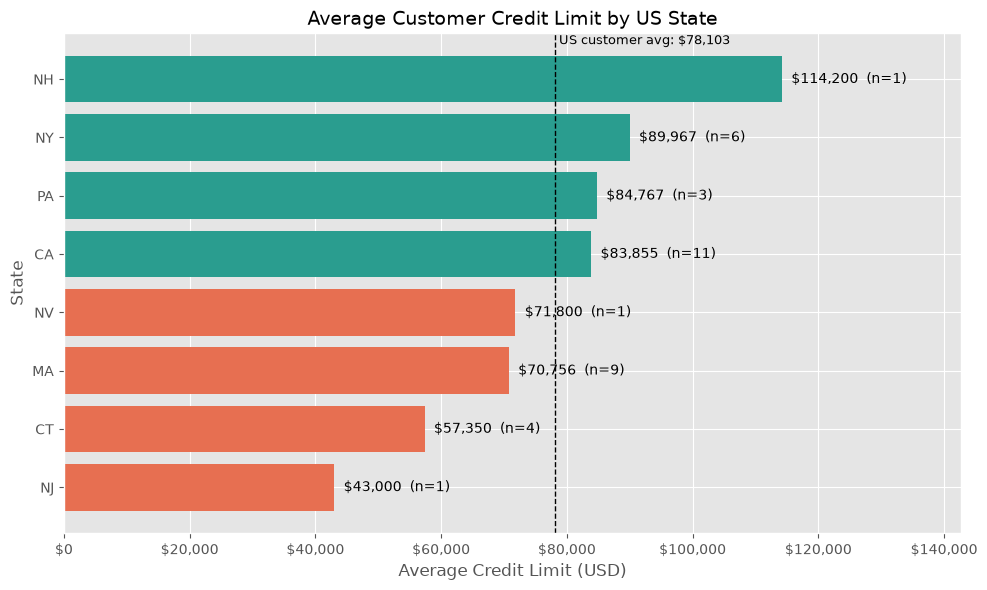

In [5]:
# Produce a visual to represent the average credit limit by state
plot_df = usa_credit_by_state.sort_values('avg_credit_limit')
overall_avg = (plot_df['avg_credit_limit'] * plot_df['num_customers']).sum() / plot_df['num_customers'].sum()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2a9d8f' if v >= overall_avg else '#e76f51' for v in plot_df['avg_credit_limit']]
bars = ax.barh(plot_df['state'], plot_df['avg_credit_limit'], color=colors)

# Annotate each bar with the average and the number of customers behind it
for bar, avg, n in zip(bars, plot_df['avg_credit_limit'], plot_df['num_customers']):
    ax.text(bar.get_width() + 1500, bar.get_y() + bar.get_height() / 2,
            f'${avg:,.0f}  (n={n})', va='center', fontsize=10)

ax.axvline(overall_avg, color='black', linestyle='--', linewidth=1)
ax.text(overall_avg, len(plot_df) - 0.4, f' US customer avg: ${overall_avg:,.0f}', fontsize=9)

ax.set_title('Average Customer Credit Limit by US State', fontsize=14)
ax.set_xlabel('Average Credit Limit (USD)')
ax.set_ylabel('State')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(0, plot_df['avg_credit_limit'].max() * 1.25)
plt.tight_layout()
plt.show()

### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [6]:
top_10_customers = pd.read_sql("""
SELECT c.customerNumber,
       c.customerName,
       ROUND(SUM(CAST(p.amount AS REAL)), 2) AS total_payments
  FROM customers c
  JOIN payments p
    ON c.customerNumber = p.customerNumber
 GROUP BY c.customerNumber, c.customerName
 ORDER BY total_payments DESC
 LIMIT 10;
""", conn)
top_10_customers

,customerNumber,customerName,total_payments
0,141,Euro+ Shopping Channel,715738.98
1,124,Mini Gifts Distributors Ltd.,584188.24
2,114,"Australian Collectors, Co.",180585.07
3,151,Muscle Machine Inc,177913.95
4,148,"Dragon Souveniers, Ltd.",156251.03
5,323,"Down Under Souveniers, Inc",154622.08
6,187,"AV Stores, Co.",148410.09
7,276,"Anna's Decorations, Ltd",137034.22
8,321,Corporate Gift Ideas Co.,132340.78
9,146,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

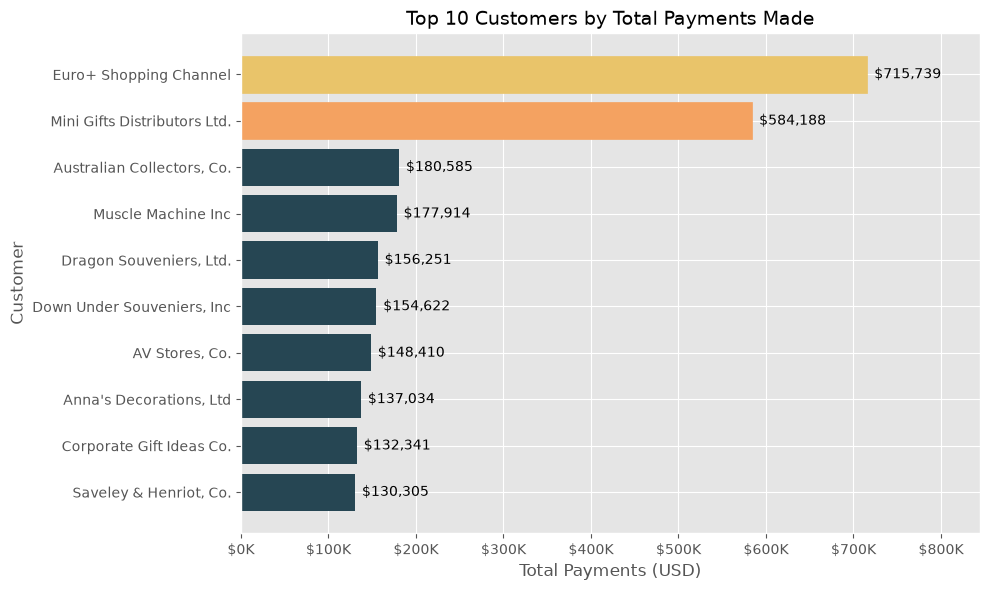

In [7]:
# Produce a visual to represent the top ten customers in terms of total payments
plot_df = top_10_customers.sort_values('total_payments')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_df['customerName'], plot_df['total_payments'], color='#264653')
bars[-1].set_color('#e9c46a')  # highlight the #1 customer
bars[-2].set_color('#f4a261')  # and the #2 customer

for bar in bars:
    ax.text(bar.get_width() + 8000, bar.get_y() + bar.get_height() / 2,
            f'${bar.get_width():,.0f}', va='center', fontsize=10)

ax.set_title('Top 10 Customers by Total Payments Made', fontsize=14)
ax.set_xlabel('Total Payments (USD)')
ax.set_ylabel('Customer')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
ax.set_xlim(0, plot_df['total_payments'].max() * 1.18)
plt.tight_layout()
plt.show()

### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [8]:
customer_product_quantities = pd.read_sql("""
SELECT c.customerNumber,
       c.customerName,
       p.productCode,
       p.productName,
       SUM(CAST(od.quantityOrdered AS INTEGER)) AS total_quantity
  FROM customers c
  JOIN orders o
    ON c.customerNumber = o.customerNumber
  JOIN orderdetails od
    ON o.orderNumber = od.orderNumber
  JOIN products p
    ON od.productCode = p.productCode
 GROUP BY c.customerNumber, c.customerName, p.productCode, p.productName
HAVING SUM(CAST(od.quantityOrdered AS INTEGER)) >= 10
 ORDER BY total_quantity ASC;
""", conn)
customer_product_quantities

,customerNumber,customerName,productCode,productName,total_quantity
0,314,Petit Auto,S18_2949,1913 Ford Model T Speedster,10
1,412,"Extreme Desk Decorations, Ltd",S24_4620,1961 Chevrolet Impala,10
2,119,La Rochelle Gifts,S32_2509,1954 Greyhound Scenicruiser,11
3,328,Tekni Collectables Inc.,S700_1691,American Airlines: B767-300,11
4,450,The Sharp Gifts Warehouse,S24_3191,1969 Chevrolet Camaro Z28,13
...,...,...,...,...,...
2526,141,Euro+ Shopping Channel,S24_3432,2002 Chevy Corvette,174
2527,141,Euro+ Shopping Channel,S12_4473,1957 Chevy Pickup,183
2528,141,Euro+ Shopping Channel,S24_1444,1970 Dodge Coronet,197
2529,141,Euro+ Shopping Channel,S24_2840,1958 Chevy Corvette Limited Edition,245


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [9]:
# LEFT JOIN from products so a product that has never been ordered still counts
# toward its line's product total. COUNT(DISTINCT ...) is needed because each
# product appears on many order lines after the join.
product_line_summary = pd.read_sql("""
SELECT p.productLine,
       COUNT(DISTINCT p.productCode)                          AS num_products,
       COALESCE(SUM(CAST(od.quantityOrdered AS INTEGER)), 0)  AS total_quantity_ordered
  FROM products p
  LEFT JOIN orderdetails od
    ON p.productCode = od.productCode
 GROUP BY p.productLine
 ORDER BY total_quantity_ordered DESC;
""", conn)
product_line_summary

,productLine,num_products,total_quantity_ordered
0,Classic Cars,38,35582
1,Vintage Cars,24,22933
2,Motorcycles,13,12778
3,Planes,12,11872
4,Trucks and Buses,11,11001
5,Ships,9,8532
6,Trains,3,2818


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

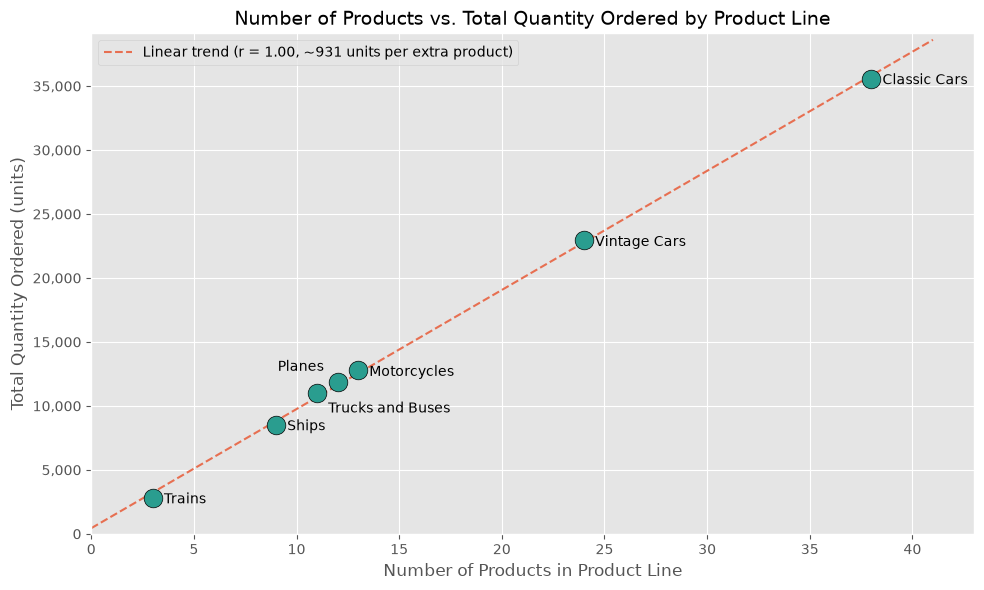

In [10]:
# Produce a visual to represent the the relation between number of products and the total amount ordered
import numpy as np

x = product_line_summary['num_products']
y = product_line_summary['total_quantity_ordered']
slope, intercept = np.polyfit(x, y, 1)
r = np.corrcoef(x, y)[0, 1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, s=180, color='#2a9d8f', edgecolor='black', zorder=3)

xs = np.linspace(0, x.max() + 3, 100)
ax.plot(xs, slope * xs + intercept, linestyle='--', color='#e76f51',
        label=f'Linear trend (r = {r:.2f}, ~{slope:,.0f} units per extra product)')

label_offsets = {'Planes': (-10, 8), 'Trucks and Buses': (8, -14)}  # avoid overlapping labels
for _, row in product_line_summary.iterrows():
    dx, dy = label_offsets.get(row['productLine'], (8, -4))
    ax.annotate(row['productLine'], (row['num_products'], row['total_quantity_ordered']),
                xytext=(dx, dy), textcoords='offset points', fontsize=10,
                ha='right' if dx < 0 else 'left')

ax.set_title('Number of Products vs. Total Quantity Ordered by Product Line', fontsize=14)
ax.set_xlabel('Number of Products in Product Line')
ax.set_ylabel('Total Quantity Ordered (units)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_xlim(0, x.max() + 5)
ax.set_ylim(0, y.max() * 1.1)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

**Answer:**

I used a **scatter plot**, with each dot representing one product line. The question is about the *relationship* between two numbers: "if a line has more products, does it also sell more units?" A scatter plot is built for this. It puts one number on the horizontal axis (how many products the line has) and the other on the vertical axis (how many units were ordered), so you can see whether the dots rise together. A bar chart would show each number on its own but would make you compare two sets of bars by eye. I labeled every dot with its product line name and added a dashed trend line to make the pattern easy to read.

**What it shows:** the dots fall almost exactly on a straight upward line (correlation ≈ 1.0). Product lines with more products sell proportionally more units. Classic Cars (38 products) sell the most by far, and Trains (3 products) sell the least. Every line sells roughly 930–1,000 units *per product* (the trend line adds about 930 units for each extra product), so demand per product is very consistent across lines. So far, adding products to a line tends to add orders at about the same rate, which supports expanding the range of popular lines like Classic Cars and Vintage Cars. One caveat: this shows a correlation, not proof of cause. The chart has only 7 data points, and more products could simply reflect lines that were already popular.

### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [11]:
remote_office_employees = pd.read_sql("""
SELECT e.employeeNumber,
       e.firstName,
       e.lastName,
       e.email,
       e.jobTitle,
       e.officeCode,
       o.city                              AS officeCity,
       o.country                           AS officeCountry,
       e.reportsTo                         AS supervisorNumber,
       s.firstName || ' ' || s.lastName    AS supervisorName,
       s.jobTitle                          AS supervisorJobTitle
  FROM employees e
  JOIN offices o
    ON e.officeCode = o.officeCode
  LEFT JOIN employees s
    ON e.reportsTo = s.employeeNumber
 WHERE e.officeCode IN (
        SELECT officeCode
          FROM employees
         GROUP BY officeCode
        HAVING COUNT(*) < 5
       )
 ORDER BY e.officeCode, e.lastName;
""", conn)
remote_office_employees

,employeeNumber,firstName,lastName,email,jobTitle,officeCode,officeCity,officeCountry,supervisorNumber,supervisorName,supervisorJobTitle
0,1188,Julie,Firrelli,jfirrelli@classicmodelcars.com,Sales Rep,2,Boston,USA,1143,Anthony Bow,Sales Manager (NA)
1,1216,Steve,Patterson,spatterson@classicmodelcars.com,Sales Rep,2,Boston,USA,1143,Anthony Bow,Sales Manager (NA)
2,1286,Foon Yue,Tseng,ftseng@classicmodelcars.com,Sales Rep,3,NYC,USA,1143,Anthony Bow,Sales Manager (NA)
3,1323,George,Vanauf,gvanauf@classicmodelcars.com,Sales Rep,3,NYC,USA,1143,Anthony Bow,Sales Manager (NA)
4,1625,Yoshimi,Kato,ykato@classicmodelcars.com,Sales Rep,5,Tokyo,Japan,1621,Mami Nishi,Sales Rep
5,1621,Mami,Nishi,mnishi@classicmodelcars.com,Sales Rep,5,Tokyo,Japan,1056,Mary Patterson,VP Sales
6,1611,Andy,Fixter,afixter@classicmodelcars.com,Sales Rep,6,Sydney,Australia,1088,William Patterson,Sales Manager (APAC)
7,1619,Tom,King,tking@classicmodelcars.com,Sales Rep,6,Sydney,Australia,1088,William Patterson,Sales Manager (APAC)
8,1612,Peter,Marsh,pmarsh@classicmodelcars.com,Sales Rep,6,Sydney,Australia,1088,William Patterson,Sales Manager (APAC)
9,1088,William,Patterson,wpatterson@classicmodelcars.com,Sales Manager (APAC),6,Sydney,Australia,1056,Mary Patterson,VP Sales


## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

**Answer:**

I split the problem into two questions: *which offices are small?* and *who works in those offices?*

- **The subquery answers the first question.** `SELECT officeCode FROM employees GROUP BY officeCode HAVING COUNT(*) < 5` groups employees by office and counts them. `HAVING` (not `WHERE`) filters on that count, because the count only exists after grouping. The result is just a list of office codes (2, 3, 5, 6, 7). Offices 1 (6 employees) and 4 (5 employees) are dropped. I used a subquery instead of typing those codes by hand so the query stays correct as staff are hired or leave.
- **The main query answers the second question.** `WHERE e.officeCode IN (subquery)` keeps only employees whose office code is in that list. The main query then adds the context management asked for. It joins `offices` for the office city and country, and it self-joins `employees` a second time (aliased `s`) on `e.reportsTo = s.employeeNumber` to get each employee's supervisor name and job title. I used a `LEFT JOIN` for the supervisor so that an employee with no supervisor (such as the President) would not be silently dropped.

### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [12]:
conn.close()

### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [13]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

### 2.1 Initial Exploration: size and scope of the data

All exploration below excludes movies with `start_year > 2019` (per the instructions) and excludes null values in the fields being analyzed instead of filling them in.

In [14]:
# Row counts for every table
table_counts = pd.read_sql("""
SELECT 'movie_basics'  AS table_name, COUNT(*) AS num_rows FROM movie_basics  UNION ALL
SELECT 'movie_ratings',              COUNT(*)             FROM movie_ratings UNION ALL
SELECT 'movie_akas',                 COUNT(*)             FROM movie_akas    UNION ALL
SELECT 'persons',                    COUNT(*)             FROM persons       UNION ALL
SELECT 'principals',                 COUNT(*)             FROM principals    UNION ALL
SELECT 'directors',                  COUNT(*)             FROM directors     UNION ALL
SELECT 'writers',                    COUNT(*)             FROM writers       UNION ALL
SELECT 'known_for',                  COUNT(*)             FROM known_for;
""", conn4)
table_counts

,table_name,num_rows
0,movie_basics,146144
1,movie_ratings,73856
2,movie_akas,331703
3,persons,606648
4,principals,1028186
5,directors,291174
6,writers,255873
7,known_for,1638260


In [15]:
# Movies per release year (and how many fall outside the valid 2010-2019 window)
movies_per_year = pd.read_sql("""
SELECT start_year,
       COUNT(*) AS num_movies
  FROM movie_basics
 GROUP BY start_year
 ORDER BY start_year;
""", conn4)
movies_per_year

,start_year,num_movies
0,2010,11849
1,2011,12900
2,2012,13787
3,2013,14709
4,2014,15589
5,2015,16243
6,2016,17272
7,2017,17504
8,2018,16849
9,2019,8379


In [16]:
# How much of movie_basics is null / out of range / unrated?
basics_quality = pd.read_sql("""
SELECT COUNT(*)                                                  AS total_movies,
       SUM(start_year > 2019)                                    AS future_year_movies,
       SUM(genres IS NULL)                                       AS null_genres,
       SUM(runtime_minutes IS NULL)                              AS null_runtime,
       SUM(runtime_minutes > 300)                                AS runtime_over_5_hours,
       SUM(movie_id NOT IN (SELECT movie_id FROM movie_ratings)) AS movies_without_rating
  FROM movie_basics;
""", conn4)
basics_quality

,total_movies,future_year_movies,null_genres,null_runtime,runtime_over_5_hours,movies_without_rating
0,146144,1063,5408,31739,123,72288


In [17]:
# Distribution of ratings and vote counts for rated movies released 2010-2019
ratings_overview = pd.read_sql("""
SELECT b.movie_id, b.start_year, b.runtime_minutes, r.averagerating, r.numvotes
  FROM movie_basics b
  JOIN movie_ratings r
    ON b.movie_id = r.movie_id
 WHERE b.start_year <= 2019
   AND b.runtime_minutes IS NOT NULL;
""", conn4)

print(ratings_overview[['runtime_minutes', 'averagerating', 'numvotes']].describe().round(1))
print(f"\nShare of rated movies with fewer than 100 votes: {(ratings_overview['numvotes'] < 100).mean():.0%}")
print("\nCorrelation matrix:")
print(ratings_overview[['runtime_minutes', 'averagerating', 'numvotes']].corr().round(3))

       runtime_minutes  averagerating   numvotes
count          66236.0        66236.0    66236.0
mean              94.7            6.3     3924.1
std              208.6            1.5    31964.9
min                3.0            1.0        5.0
25%               81.0            5.5       16.0
50%               91.0            6.5       61.0
75%              104.0            7.3      347.0
max            51420.0           10.0  1841066.0

Share of rated movies with fewer than 100 votes: 58%

Correlation matrix:
                 runtime_minutes  averagerating  numvotes
runtime_minutes            1.000         -0.007     0.012
averagerating             -0.007          1.000     0.048
numvotes                   0.012          0.048     1.000


**Early observations**
- `movie_basics` has ~146K movies, but only ~74K have a rating, so about half the catalog cannot be used for any ratings analysis.
- 1,063 movies have a `start_year` after 2019 (as late as 2115!) and must be excluded. 2019 also looks incomplete (about half the volume of 2018).
- Vote counts are extremely skewed. The median rated movie has only ~60 votes, while the most-voted has 1.8M. A 7.5 rating from 20 votes is not comparable to a 7.5 from 200K votes.
- Runtime has almost **no** relationship with rating or number of votes (correlations ≈ 0). Runtime also contains impossible values (a max of 51,420 minutes).
- The `genres` column stores up to three genres as one comma-separated string (e.g. `Action,Crime,Drama`), so it must be split before genres can be compared.

Genre looks like the most promising lens, so I focus the rest of the analysis there.

### 2.2 Genre analysis: audience approval vs. audience reach

To compare genres fairly, I:
- split the multi-genre string into one row per (movie, genre) using a **recursive CTE**,
- keep only movies with **at least 1,000 votes**, so ratings are based on a meaningful audience and aren't skewed by tiny samples,
- keep only genres with at least 30 such movies.

I use `numvotes` as a proxy for **audience reach** (how many people watched it and cared enough to rate it) and `averagerating` as a proxy for **audience approval**.

In [18]:
genre_performance = pd.read_sql("""
WITH RECURSIVE clean_movies AS (
    SELECT b.movie_id,
           b.genres || ',' AS rest,
           r.averagerating,
           r.numvotes
      FROM movie_basics b
      JOIN movie_ratings r
        ON b.movie_id = r.movie_id
     WHERE b.start_year <= 2019
       AND b.genres IS NOT NULL
       AND r.numvotes >= 1000
),
split(movie_id, genre, rest, averagerating, numvotes) AS (
    SELECT movie_id, NULL, rest, averagerating, numvotes
      FROM clean_movies
    UNION ALL
    SELECT movie_id,
           substr(rest, 1, instr(rest, ',') - 1),
           substr(rest, instr(rest, ',') + 1),
           averagerating,
           numvotes
      FROM split
     WHERE rest <> ''
)
SELECT genre,
       COUNT(*)                     AS num_movies,
       ROUND(AVG(averagerating), 2) AS avg_rating,
       ROUND(AVG(numvotes))         AS avg_votes
  FROM split
 WHERE genre IS NOT NULL
 GROUP BY genre
HAVING COUNT(*) >= 30
 ORDER BY avg_rating DESC;
""", conn4)
genre_performance

,genre,num_movies,avg_rating,avg_votes
0,Documentary,741,7.27,4824.0
1,Biography,701,6.96,30359.0
2,Sport,196,6.93,18471.0
3,History,387,6.89,19595.0
4,Music,283,6.75,18583.0
5,War,163,6.72,15824.0
6,Animation,376,6.68,40310.0
7,Musical,70,6.54,18857.0
8,Drama,5047,6.49,22997.0
9,Romance,1351,6.34,19287.0


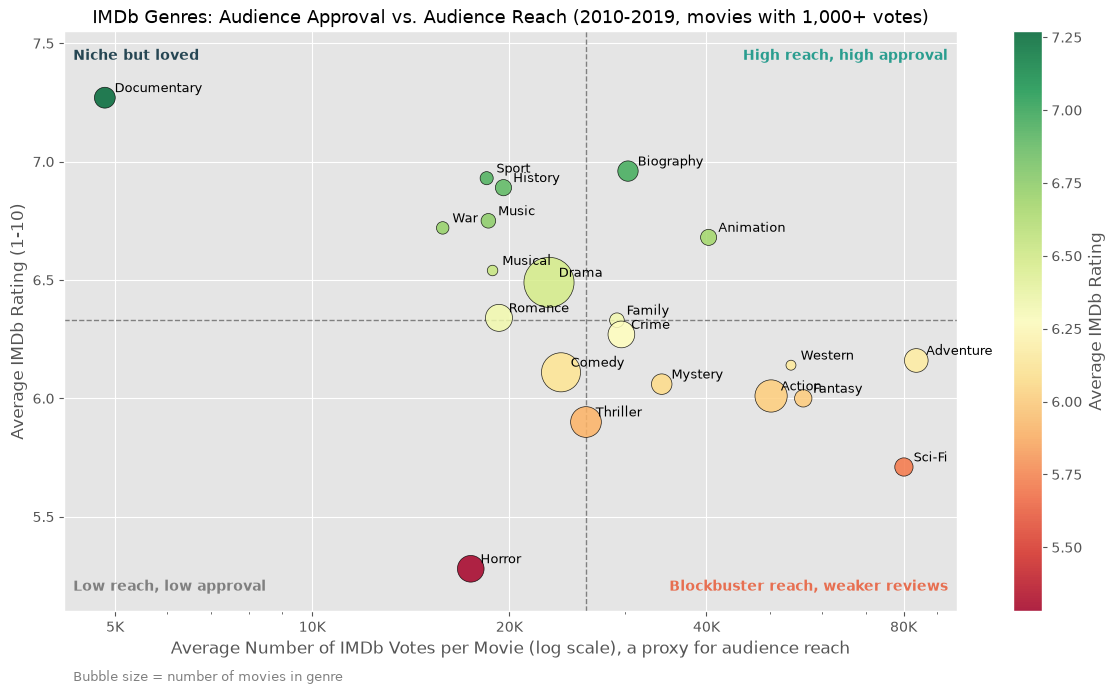

Correlation between a genre's avg rating and avg votes: -0.47


In [19]:
# Visual supporting the business question: approval (rating) vs. reach (votes) by genre
plot_df = genre_performance.copy()
med_rating = plot_df['avg_rating'].median()
med_votes = plot_df['avg_votes'].median()

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(plot_df['avg_votes'], plot_df['avg_rating'],
                s=plot_df['num_movies'] / 4 + 40, c=plot_df['avg_rating'],
                cmap='RdYlGn', edgecolor='black', alpha=0.85, zorder=3)
ax.set_xscale('log')

for _, row in plot_df.iterrows():
    ax.annotate(row['genre'], (row['avg_votes'], row['avg_rating']),
                xytext=(7, 4), textcoords='offset points', fontsize=9)

# Quadrant lines at the median genre
ax.axhline(med_rating, color='grey', linestyle='--', linewidth=1)
ax.axvline(med_votes, color='grey', linestyle='--', linewidth=1)
ax.text(0.99, 0.97, 'High reach, high approval', transform=ax.transAxes, ha='right', va='top', fontsize=10, fontweight='bold', color='#2a9d8f')
ax.text(0.01, 0.97, 'Niche but loved', transform=ax.transAxes, ha='left', va='top', fontsize=10, fontweight='bold', color='#264653')
ax.text(0.99, 0.03, 'Blockbuster reach, weaker reviews', transform=ax.transAxes, ha='right', va='bottom', fontsize=10, fontweight='bold', color='#e76f51')
ax.text(0.01, 0.03, 'Low reach, low approval', transform=ax.transAxes, ha='left', va='bottom', fontsize=10, fontweight='bold', color='grey')

ax.set_title('IMDb Genres: Audience Approval vs. Audience Reach (2010-2019, movies with 1,000+ votes)', fontsize=13)
ax.set_xlabel('Average Number of IMDb Votes per Movie (log scale), a proxy for audience reach')
ax.set_ylabel('Average IMDb Rating (1-10)')
ax.set_xticks([5000, 10000, 20000, 40000, 80000])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:,.0f}K'))
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_ylim(5.1, 7.55)
plt.colorbar(sc, label='Average IMDb Rating')
ax.text(0.01, -0.12, 'Bubble size = number of movies in genre', transform=ax.transAxes, fontsize=9, color='grey')
plt.tight_layout()
plt.savefig('images/genre_rating_vs_votes.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Correlation between a genre's avg rating and avg votes: "
      f"{plot_df['avg_rating'].corr(plot_df['avg_votes']):.2f}")

**Findings**
- There is a clear **trade-off between approval and reach**. Genres with the highest ratings (Documentary 7.3, Biography 7.0, History 6.9, Sport 6.9) attract relatively few votes. The genres that draw the biggest audiences (Adventure ~84K votes and Sci-Fi ~80K votes per movie, Fantasy, Action) rate *below* the typical genre (Sci-Fi 5.7, Action 6.0).
- **Animation** stands out as the one genre that sits clearly in the "high reach, high approval" quadrant (6.7 rating with ~40K average votes). Biography sits on the border of that quadrant.
- **Horror** is the weakest genre on both measures (lowest average rating at 5.3, with below-median reach), yet it is one of the most-produced genres. This suggests a crowded, low-return space.
- Drama and Comedy dominate by volume but sit in the middle on both measures.

### Business Question
> **Which genres (and genre combinations) give a new studio the best balance of audience reach and audience approval?** In particular, can pairing a high-reach genre (Adventure, Action, Sci-Fi) with a highly rated genre (Biography, History, Animation) produce films that beat the typical rating/reach trade-off? And is Animation's strong position consistent across 2010-2019 or driven by a few hits?

This matters because a studio's upside depends on both getting a large audience *and* earning good word of mouth. The data can answer it: the same pipeline can be run on genre *pairs* and by `start_year`.

In [20]:
# First look at the follow-up: top genre *combinations* (as listed) with 1,000+ votes and 30+ movies
genre_combos = pd.read_sql("""
SELECT b.genres,
       COUNT(*)                       AS num_movies,
       ROUND(AVG(r.averagerating), 2) AS avg_rating,
       ROUND(AVG(r.numvotes))         AS avg_votes
  FROM movie_basics b
  JOIN movie_ratings r
    ON b.movie_id = r.movie_id
 WHERE b.start_year <= 2019
   AND b.genres IS NOT NULL
   AND r.numvotes >= 1000
 GROUP BY b.genres
HAVING COUNT(*) >= 30
 ORDER BY avg_votes DESC
 LIMIT 10;
""", conn4)
genre_combos

,genres,num_movies,avg_rating,avg_votes
0,"Action,Adventure,Sci-Fi",77,6.18,298904.0
1,"Action,Adventure,Fantasy",64,5.69,150775.0
2,"Action,Adventure,Comedy",90,5.63,80282.0
3,"Adventure,Animation,Comedy",122,6.36,70958.0
4,"Action,Comedy,Crime",84,6.02,55468.0
5,"Action,Adventure,Animation",64,7.13,55400.0
6,"Biography,Crime,Drama",47,6.77,52901.0
7,"Action,Adventure,Drama",91,5.71,49089.0
8,"Action,Sci-Fi,Thriller",36,5.44,48940.0
9,"Biography,Comedy,Drama",50,7.05,48316.0


### 2.3 Data Cleaning Tasks Identified

Tasks needed before a deeper version of this analysis (identified only, not performed):

1. **Filter out invalid years.** Drop the 1,063 movies with `start_year > 2019`, and treat 2019 as a partial year when comparing trends over time.
2. **Normalize the `genres` column.** It holds up to three genres in one comma-separated string. Split it into a `movie_genres` bridge table (one row per movie per genre) so genres can be joined and counted properly.
3. **Handle nulls by exclusion.** 5,408 movies have null `genres` and ~31.7K have null `runtime_minutes`. `persons.birth_year`, `principals.job` and `principals.characters`, and `movie_akas.region` and `language` are also heavily null. Exclude these rows from the analyses that use those fields rather than imputing values.
4. **Address missing ratings.** ~71K movies (about half) have no row in `movie_ratings`. Use an inner join for ratings analyses, and note the selection bias this introduces (rated movies skew toward more popular titles).
5. **Set a minimum-votes threshold.** 58% of rated movies have fewer than 100 votes, which makes their average rating unreliable. Choose a threshold (1,000 was used here) or use a weighted rating (e.g. an IMDb-style Bayesian average).
6. **Treat runtime outliers.** Remove or cap implausible runtimes (123 movies over 5 hours, including 51,420 minutes, and ~5.2K under 40 minutes that are likely shorts or TV).
7. **Deduplicate the relationship tables.** `directors` has 291K rows but only 164K unique (movie, person) pairs, and `writers` has 256K rows but only 178K unique pairs. Remove the duplicates before counting people per movie.
8. **Check duplicate titles.** 1,870 (title, year) pairs appear more than once. Decide whether they are genuine different films or duplicate entries, using `movie_id` as the true key.
9. **Standardize text fields.** `principals.characters` is stored as a JSON-style string (`["The Man"]`), and `persons.primary_profession` is a comma-separated list. Both need parsing. `primary_title` and `original_title` differ for ~14.5K movies, so choose one consistently.
10. **Convert data types.** Store `start_year` as an integer and `runtime_minutes` as a numeric type consistently, and check that `movie_id` and `person_id` keys match across tables (no orphan IDs).

In [21]:
# Close the connection
conn4.close()